In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))


def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)


In [4]:
# XOR Dataset (4 samples)
X = np.array([[0,0], [0,1], [1,0], [1,1]])  # Input features
y = np.array([[0], [1], [1], [0]])          # XOR labels

print("Dataset:")
print("X:", X)
print("y:", y)
print()

Dataset:
X: [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [[0]
 [1]
 [1]
 [0]]



In [5]:
# Forward pass
def forward(X, W1, b1, W2, b2):
    z1 = np.dot(X, W1) + b1           # Linear: XW1 + b1
    a1 = sigmoid(z1)                  # Hidden activation
    z2 = np.dot(a1, W2) + b2          # Linear: a1W2 + b2  
    a2 = sigmoid(z2)                  # Output activation
    return z1, a1, z2, a2

In [21]:
# Backpropagation + Gradient Descent
def backprop(X, y, z1, a1, z2, a2, W1, b1, W2, b2, lr=0.1):
    m = X.shape[0]

    # Output layer gradients
    dz2 = a2 - y                          # dL/da2 * da2/dz2
    dW2 = (1/m) * np.dot(a1.T, dz2)      # ∂L/∂W2
    db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)


    # Hidden layer gradients (chain rule)
    da1 = np.dot(dz2, W2.T)              # ∂L/∂a1  
    dz1 = da1 * sigmoid_deriv(z1)        # ∂L/∂z1
    dW1 = (1/m) * np.dot(X.T, dz1)       # ∂L/∂W1
    db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
    
    # Parameter updates (Gradient Descent)
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1  
    b1 -= lr * db1
    
    return W1, b1, W2, b2


In [22]:
# Training
np.random.seed(42)
input_size, hidden_size, output_size = 2, 2, 1

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

epochs = 10000
losses = []
lr = 1.2

print("Training...")
for epoch in range(epochs):
    z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
    loss = np.mean((a2 - y)**2)
    losses.append(loss)
    
    W1, b1, W2, b2 = backprop(X, y, z1, a1, z2, a2, W1, b1, W2, b2, lr)
    
    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d}, Loss: {loss:.4f}")

Training...
Epoch     0, Loss: 0.2500
Epoch  2000, Loss: 0.2500
Epoch  4000, Loss: 0.2500
Epoch  6000, Loss: 0.2500
Epoch  8000, Loss: 0.2500


In [13]:
# Final Results
print("" + "="*50)
print("FINAL RESULTS")
print("="*50)
z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
print("Predictions:")
for i in range(4):
    print(f"Input {X[i]} -> Output {a2[i][0]:.4f} (Target: {y[i][0]})")

print(f"Final Loss: {np.mean((a2-y)**2):.4f}")

FINAL RESULTS
Predictions:
Input [0 0] -> Output 0.4951 (Target: 0)
Input [0 1] -> Output 0.4948 (Target: 1)
Input [1 0] -> Output 0.4950 (Target: 1)
Input [1 1] -> Output 0.4948 (Target: 0)
Final Loss: 0.2500


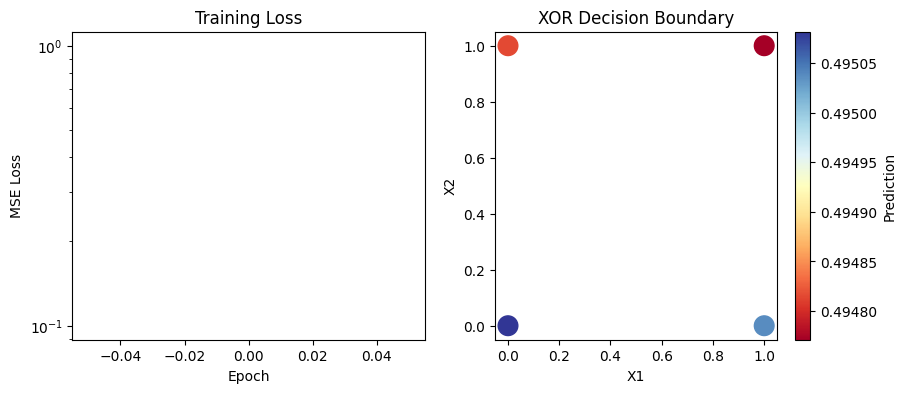

In [14]:
# Loss Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=a2, cmap='RdYlBu', s=200)
plt.title('XOR Decision Boundary')
plt.xlabel('X1')
plt.ylabel('X2')
plt.colorbar(label='Prediction')
plt.show()